In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [6]:
os.getcwd()       # görüntüyü kaydedeceğim yolu gösterecek.

'C:\\Users\\Acer'

In [8]:
# Morfolojik işlemler =Gri seviyede(tek kanallı) görüntülerin yapısal özelliklerinin 
#değiştirilmesi için kullanılan klasik görüntü işleme yöntemidir. 
#Bu yöntemin 5 temel elementi vardır.Erosion(aşınma),Dilation(Genişleme),Opening(Açılma),Closing(Kapanma),
#Gradient(Gradyan-piksel yoğunluğu hesaplama)

my_binary_1_img=cv2.imread("ders.png",0)
print(type(my_binary_1_img))

<class 'numpy.ndarray'>


In [11]:
# 1 Erosion - Aşınma, elimizdeki bir kernel (çekirdek matrisi) sayesinde,görüntüdeki beyaz renkleri aşınmaya-küçültmeye yarar.
#bu işlemi yaparken çekirdek matrisi ve görüntü arasında AND işlemi gerçekleşir.Bu sayede sadece matrisdeki 1 değeri ile 
#görüntüdeki 255 ya da 1 değeri eşleştiğinde beyaz renk sabit kalır, diğer seçeneklerde renk, siyah olur.
#Böylelikle beyaz renkler aşınmış-erosyona uğramış olur.
#Amaç: Küçük nesneleri veya gürültüyü kaldırmak.

#işlemi yapacağız ve içi 1 değeriyle dolu olan matrisimizi oluşturuyoruz.
my_kernel= np.ones((5,5),dtype=np.uint8)

In [12]:
my_erosion_img=cv2.erode(my_binary_1_img,my_kernel,iterations=6)    #iterasyon sayısına göre aşınacak

Text(0.5, 1.0, 'Erosion Image')

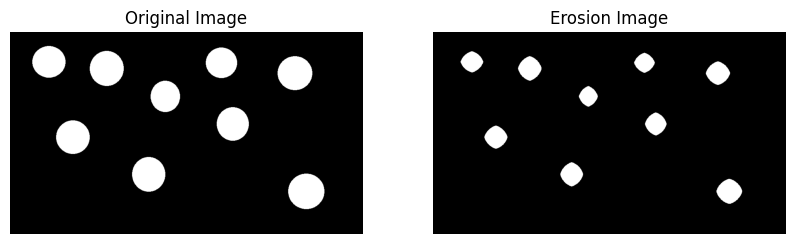

In [14]:
fig=plt.figure(figsize=(10,7))

plt.subplot(1,2,1)
plt.imshow(my_binary_1_img,cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(my_erosion_img,cmap="gray")
plt.axis("off")
plt.title("Erosion Image")

Text(0.5, 1.0, 'Dilation Image')

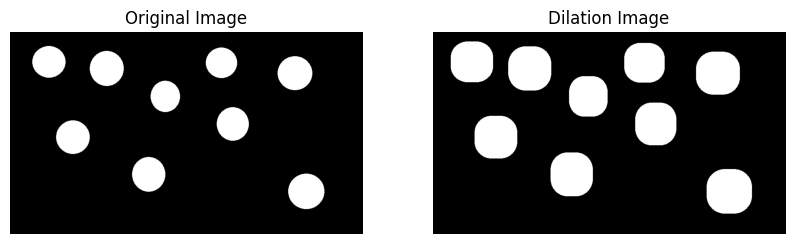

In [18]:
# 2 Dilation - Genişleme = beyaz genişliyor erosion tersi gibi düşünülebilir.
#Amaç: Nesneleri kalınlaştırmak, boşlukları doldurmak.

my_dilation_img=cv2.dilate(my_binary_1_img,my_kernel,iterations=6)

fig=plt.figure(figsize=(10,7))
#satır ,sütun, görüntünün yeri

plt.subplot(1,2,1)
plt.imshow(my_binary_1_img,cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(my_dilation_img,cmap="gray")
plt.axis("off")
plt.title("Dilation Image")


In [19]:
new_img=cv2.imread("ders2.png",0)

In [21]:
print(type(new_img))
new_img.shape

<class 'numpy.ndarray'>


(478, 600)

In [23]:
#Beyaz renkli bir gürültü oluşturuyoruz
#Gürültü(noise), seslerde istenmeyen frekans,gürültülerde istenmeyen piksel demektir.

my_white_noise=np.random.randint(0,2,size=new_img.shape[:2])     #gürültü üret 
my_white_noise*=255    

Text(0.5, 1.0, 'White Noise')

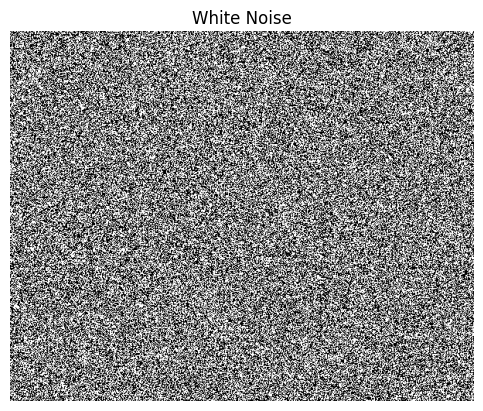

In [26]:
plt.imshow(my_white_noise,cmap="gray")
plt.axis("off")
plt.title("White Noise")

Text(0.5, 1.0, 'Noised Image')

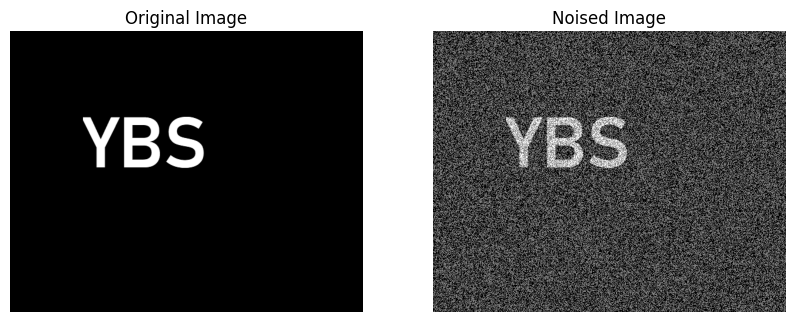

In [27]:
# gürültü olan resim ve normal resimi topladık.
my_noised_img_1=my_white_noise+new_img

fig=plt.figure(figsize=(10,7))
#satır ,sütun, görüntünün yeri

plt.subplot(1,2,1)
plt.imshow(new_img,cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(my_noised_img_1,cmap="gray")
plt.axis("off")
plt.title("Noised Image")

Text(0.5, 1.0, 'Opening Image')

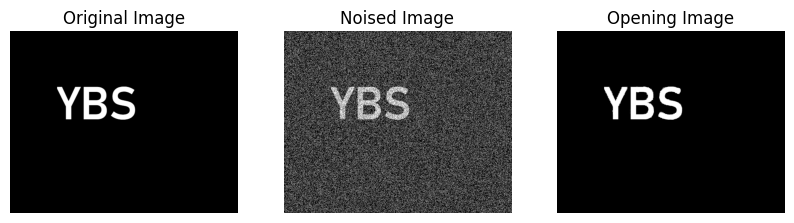

In [29]:
# 3 Opening - Açılma =  Erosion ardından Dilation işleminin uygulanmasıdır.
#Açılma işlemi, görüntüdeki küçük beyaz gürültüleri temizlemek için kullanılır.
#Amaç: Gürültüyü kaldırmak ama nesne boyutlarını korumak.

my_opening_img=cv2.morphologyEx(my_noised_img_1.astype(np.float32),cv2.MORPH_OPEN,my_kernel)   #gürültülü resim(tipi float alıyor),
                                                                                               #cv2'nin MORPH_OPEN fonksiyonu,1 değeri ile dolu matris

fig=plt.figure(figsize=(10,7))
#satır ,sütun, görüntünün yeri

plt.subplot(1,3,1)
plt.imshow(new_img,cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(my_noised_img_1,cmap="gray")
plt.axis("off")
plt.title("Noised Image")

plt.subplot(1,3,3)
plt.imshow(my_opening_img,cmap="gray")
plt.axis("off")
plt.title("Opening Image")            #Gürültü giderilmiş resim

In [30]:
#Closing - Kapanma =Dilation ardından Erosion işleminin uygulanmasıdır. Beyaz bölgelerdeki küçük siyah delikleri kapatmak için kullanılır.
#Amaç: Küçük siyah boşlukları doldurmak, kenarları düzgünleştirmek.

# Siyah gürültü oluşturma

my_black_noise=np.random.randint(0,2,size=new_img.shape[:2])     #gürültü üret 
my_black_noise*=-255                                             #siyah gürültü olduğu için negatif değerlerle çalışıyoruz.



Text(0.5, 1.0, 'Black Noise')

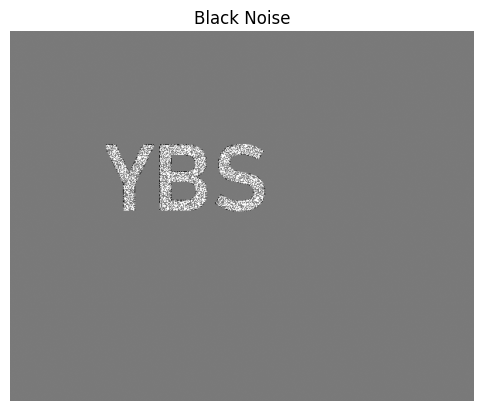

In [32]:
# Siyah gürültü olan resim ve normal resimi topladık.
my_noised_img_2=my_black_noise+new_img

#true dönenlerin değerlerini getirir
#siyahları blurlaştırıyor siyahları gürültü olarak gösteriyoruz
my_noised_img_2[my_noised_img_2<=-245]=0           #son değere yakın seçtik o yüzden -245

plt.imshow(my_noised_img_2,cmap="gray")
plt.axis("off")
plt.title("Black Noise")

In [33]:
my_closing_img=cv2.morphologyEx(my_noised_img_2.astype(np.float32),cv2.MORPH_CLOSE,my_kernel)

Text(0.5, 1.0, 'Closing Image')

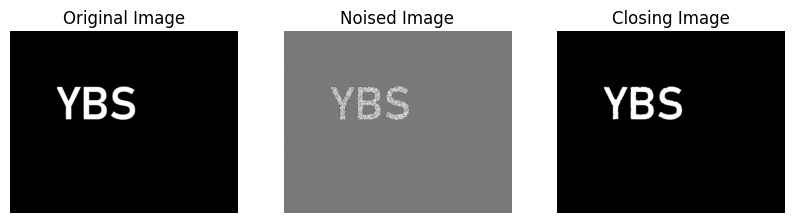

In [36]:
fig=plt.figure(figsize=(10,7))
#satır ,sütun, görüntünün yeri

plt.subplot(1,3,1)
plt.imshow(new_img,cmap="gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(my_noised_img_2,cmap="gray")
plt.axis("off")
plt.title("Noised Image")

plt.subplot(1,3,3)
plt.imshow(my_closing_img,cmap="gray")
plt.axis("off")
plt.title("Closing Image")

In [37]:
#Gradient - Gradyan = Kenar bulma piksel yoğunluğu değiştikce kenar tespit edilir. 
#Dilation ile Erosion arasındaki fark alınır. Bu, görüntünün kenarlarını belirgin hale getirir.
#Amaç: Kenar (contour) bilgilerini çıkarmak.

my_gradient_1=cv2.morphologyEx(my_binary_1_img,cv2.MORPH_GRADIENT,my_kernel)
my_gradient_2=cv2.morphologyEx(new_img,cv2.MORPH_GRADIENT,my_kernel)

Text(0.5, 1.0, 'Gradient-2 Image')

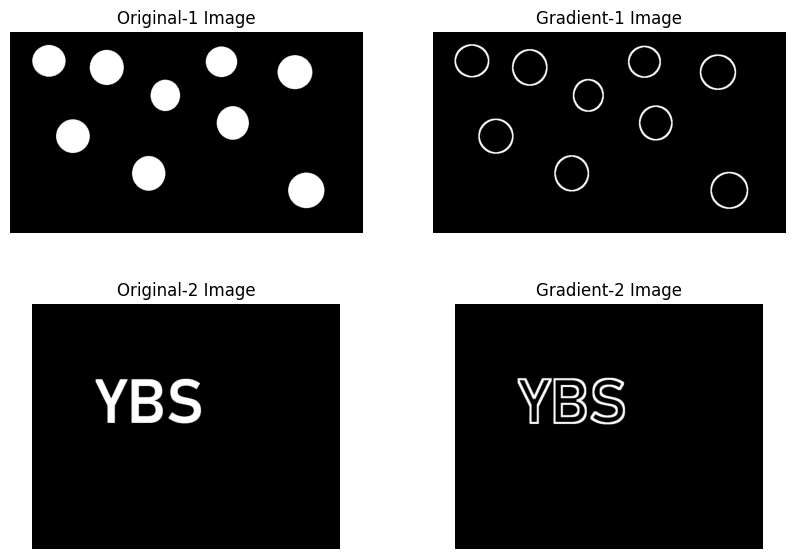

In [38]:
fig=plt.figure(figsize=(10,7))
#satır ,sütun, görüntünün yeri

plt.subplot(2,2,1)
plt.imshow(my_binary_1_img,cmap="gray")
plt.axis("off")
plt.title("Original-1 Image")

plt.subplot(2,2,2)
plt.imshow(my_gradient_1,cmap="gray")
plt.axis("off")
plt.title("Gradient-1 Image")

plt.subplot(2,2,3)
plt.imshow(new_img,cmap="gray")
plt.axis("off")
plt.title("Original-2 Image")

plt.subplot(2,2,4)
plt.imshow(my_gradient_2,cmap="gray")
plt.axis("off")
plt.title("Gradient-2 Image")

In [ ]:
# 